# Preprocessing

## Spectral Band Selection

The scenes I downloaded contain images from 13 different spectral bands from the Sentinel-2 MSI; 4 visible bands, 6 near-infrared bands and 3 short-wave infrared bands. From these there are only a handful I will need for my NBR and dNBR analysis:
1. B8A - Near-Infrared
2. B12 - Short-Wave Infrared
3. SCL - Scene Classification data

Optional for true-color composite:
1. B02 - Blue
2. B03 - Green
3. B04 - Red

The first 2 bands are the basis of my NBR and dNBR analysis. Near-infrared is strongly reflected from healthy vegetation, and very weakly from burned or bare areas, while short-wave infrared is strongly reflected from burned or bare areas, and very weakly from vegetation. It is the ratio between these 2 that gives me a clean signal for burn severity due to their contrast.

The SCL band classifies each pixel in the scene per type, such as "cloud", "shadow", "vegetation", "water", etc. I will use this data to mask out clouds and shadows before computing NBR so they don't contaminate the results due to clouds' very high reflectance across all spectral bands, and shadows' low reflectance would make cloud areas appear as healthy vegetation and shadowed areas appear burned respectively

I will store the paths to the images in the bands I selected in variables for both the pre-fire and post-fire scene

In [1]:
pre_b8a    = "data/raw/S2B_MSIL2A_20180702T104019_N0500_R008_T33VWJ_20230712T235932.SAFE/GRANULE/L2A_T33VWJ_A006898_20180702T104021/IMG_DATA/R20m/T33VWJ_20180702T104019_B8A_20m.jp2"
pre_b12    = "data/raw/S2B_MSIL2A_20180702T104019_N0500_R008_T33VWJ_20230712T235932.SAFE/GRANULE/L2A_T33VWJ_A006898_20180702T104021/IMG_DATA/R20m/T33VWJ_20180702T104019_B12_20m.jp2"
pre_scl    = "data/raw/S2B_MSIL2A_20180702T104019_N0500_R008_T33VWJ_20230712T235932.SAFE/GRANULE/L2A_T33VWJ_A006898_20180702T104021/IMG_DATA/R20m/T33VWJ_20180702T104019_SCL_20m.jp2"
pre_blue   = "data/raw/S2B_MSIL2A_20180702T104019_N0500_R008_T33VWJ_20230712T235932.SAFE/GRANULE/L2A_T33VWJ_A006898_20180702T104021/IMG_DATA/R20m/T33VWJ_20180702T104019_B02_20m.jp2"
pre_green  = "data/raw/S2B_MSIL2A_20180702T104019_N0500_R008_T33VWJ_20230712T235932.SAFE/GRANULE/L2A_T33VWJ_A006898_20180702T104021/IMG_DATA/R20m/T33VWJ_20180702T104019_B03_20m.jp2"
pre_red    = "data/raw/S2B_MSIL2A_20180702T104019_N0500_R008_T33VWJ_20230712T235932.SAFE/GRANULE/L2A_T33VWJ_A006898_20180702T104021/IMG_DATA/R20m/T33VWJ_20180702T104019_B04_20m.jp2"

post_b8a   = "data/raw/S2B_MSIL2A_20180821T104019_N0500_R008_T33VWJ_20230822T134707.SAFE/GRANULE/L2A_T33VWJ_A007613_20180821T104015/IMG_DATA/R20m/T33VWJ_20180821T104019_B8A_20m.jp2"
post_b12   = "data/raw/S2B_MSIL2A_20180821T104019_N0500_R008_T33VWJ_20230822T134707.SAFE/GRANULE/L2A_T33VWJ_A007613_20180821T104015/IMG_DATA/R20m/T33VWJ_20180821T104019_B12_20m.jp2"
post_scl   = "data/raw/S2B_MSIL2A_20180821T104019_N0500_R008_T33VWJ_20230822T134707.SAFE/GRANULE/L2A_T33VWJ_A007613_20180821T104015/IMG_DATA/R20m/T33VWJ_20180821T104019_SCL_20m.jp2"
post_blue  = "data/raw/S2B_MSIL2A_20180821T104019_N0500_R008_T33VWJ_20230822T134707.SAFE/GRANULE/L2A_T33VWJ_A007613_20180821T104015/IMG_DATA/R20m/T33VWJ_20180821T104019_B02_20m.jp2"
post_green = "data/raw/S2B_MSIL2A_20180821T104019_N0500_R008_T33VWJ_20230822T134707.SAFE/GRANULE/L2A_T33VWJ_A007613_20180821T104015/IMG_DATA/R20m/T33VWJ_20180821T104019_B03_20m.jp2"
post_red   = "data/raw/S2B_MSIL2A_20180821T104019_N0500_R008_T33VWJ_20230822T134707.SAFE/GRANULE/L2A_T33VWJ_A007613_20180821T104015/IMG_DATA/R20m/T33VWJ_20180821T104019_B04_20m.jp2"

## True-color Composite

Before I begin any processing, I can take blue, green, and red bands of my pre-fire (or post-fire) scene to create a composite image that shows the scene in true color. I will create a simple function to read the spectral band of an image, then combine the 3 bands into a true-color composite

In [2]:
import rasterio

def read_band(jp2_image_path: str):
    with rasterio.open(jp2_image_path) as src:
        band = src.read(1).astype(float) / 10000.0  # Cast to float and divide since data is stored as space-efficient integers
    return band

In [3]:
blue = read_band(pre_blue)
green = read_band(pre_green)
red = read_band(pre_red)

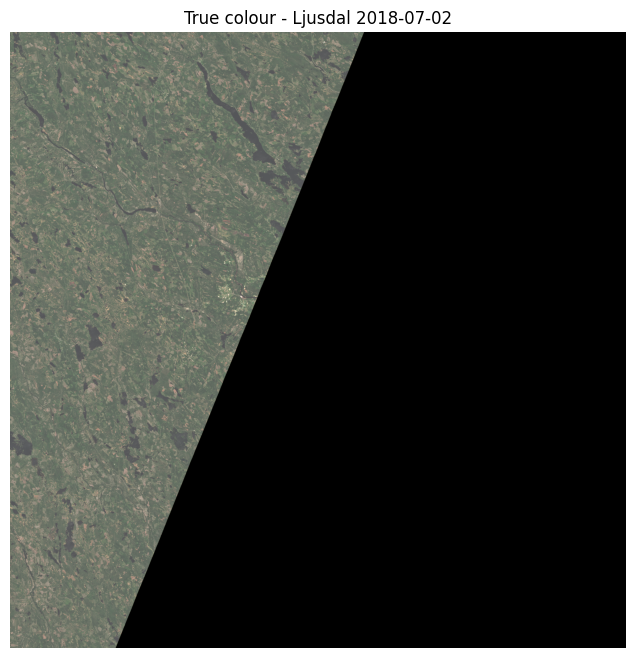

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Stack bands
rgb = np.stack([red, green, blue], axis=-1)
rgb = np.clip(rgb, 0, 0.3) / 0.3  # Stretch values to 0-1 

# Create the matplotlib figure
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("True colour - Ljusdal 2018-07-02")
plt.axis("off")

# Save the figure
os.makedirs("data/processed", exist_ok=True)
plt.savefig("data/processed/true_colour_pre.png", dpi=150, bbox_inches="tight")

plt.show()

We can also do the same for the post-fire scene

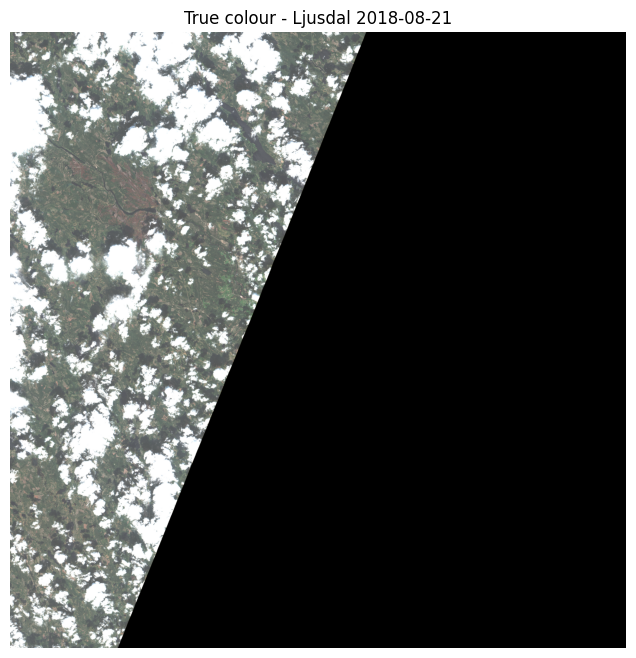

In [5]:
blue = read_band(post_blue)
green = read_band(post_green)
red = read_band(post_red)

rgb = np.stack([red, green, blue], axis=-1)
rgb = np.clip(rgb, 0, 0.3) / 0.3  # Stretch values to 0-1 

# Create the matplotlib figure
plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.title("True colour - Ljusdal 2018-08-21")
plt.axis("off")

# Save the figure
os.makedirs("data/processed", exist_ok=True)
plt.savefig("data/processed/true_colour_post.png", dpi=150, bbox_inches="tight")

plt.show()

Immediately I can see that the scenes I have cover a large area, much larger than my AOI where the fire happened (mid-upper left corner). Next I will clip the scenes to fit the fire area.

## AOI Clipping

My downloaded scenes do contain my AOI, but they also cover an area much larger than it, I will have to clip my scenes to cover only my AOI.

I will clip my scenes to my AOI coordinates (also defined in notebook 01), but since the CRS (Coordinate Reference System) of my AOI and scenes do not match, I will have to reproject the AOI coordinates to match the scene's CRS

In [6]:
aoi = {"type":"Polygon","coordinates":[[[15.112381,62.07592],[15.621872,62.07592],[15.621872,61.87687],[15.112381,61.87687],[15.112381,62.07592]]]}

In [7]:
# Find out the target CRS
with rasterio.open(pre_b8a) as src:
    target_crs = src.crs

In [8]:
from rasterio.warp import transform_geom

def reproject_aoi_coordinates(aoi: dict, target_crs: str):
    aoi_projected = transform_geom("EPSG:4326", target_crs, aoi)
    return aoi_projected

aoi = reproject_aoi_coordinates(aoi, target_crs)
print(aoi)

{'type': 'Polygon', 'coordinates': [[(505871.5573542248, 6882642.846147641), (532490.5295808289, 6882793.552656878), (532702.98628742, 6860619.990116306), (505909.9510247592, 6860468.578347641), (505871.5573542248, 6882642.846147641)]]}


With the AOI reprojected to the correct CRS, I can now clip my scenes using it. I will expand my "read_band" function to contain the logic for this since it originally only returns the band, not any other metadata.

In [9]:
from rasterio.mask import mask

def read_band_clipped(scene_path: str, aoi: dict, scale: bool = True):
    with rasterio.open(scene_path) as src:
        clipped, transform = mask(src, [aoi], crop=True)

        meta = src.meta.copy()
        meta.update({
            "driver": "GTiff",
            "height": clipped.shape[1],
            "width": clipped.shape[2],
            "transform": transform
        })

        band = clipped[0].astype(float)
        if scale:
            band /= 10000.0
    return band, meta

In [10]:
bands = [
    (pre_b8a,  True),
    (pre_b12,  True),
    (pre_scl,  False),
    (post_b8a, True),
    (post_b12, True),
    (post_scl, False),
]

(pre_nir, meta), (pre_swir, _), (pre_scl, _), \
(post_nir, _), (post_swir, _), (post_scl, _) = [read_band_clipped(p, aoi, scale=s) for p, s in bands]

I will display one of the bands to see if my clipping worked correctly.

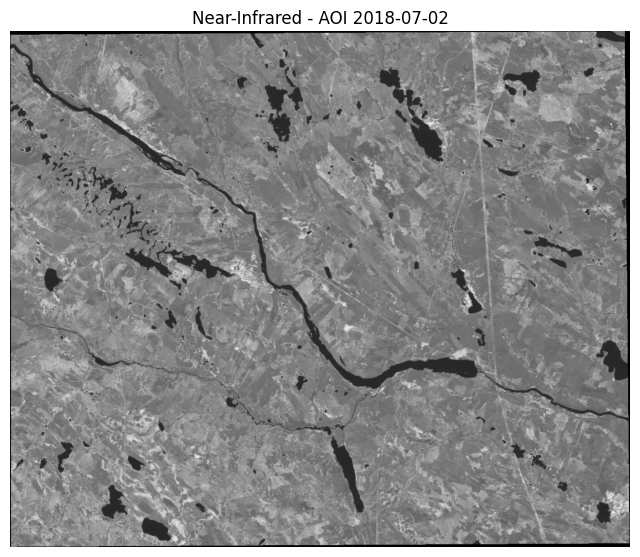

In [11]:
plt.figure(figsize=(8, 8))
plt.imshow(pre_nir, cmap="grey")
plt.title("Near-Infrared - AOI 2018-07-02")
plt.axis("off")

plt.show()

This is indeed the AOI I have selected, now I'll mask the cloud and shadow areas on the post-fire scene using the SCL band since they contaminate reflectance values by raising apparent near-infrared and short-wave infrared unevenly.

## SCL Cloud & Shadow Masking

First I will define the SCL classes to mask (clouds, shadow, no-data) and create a boolean mask for them so I can set each pixel corresponding to one of the classes to NaN in my bands.

In [12]:
assert pre_nir.shape == pre_swir.shape == post_nir.shape == post_swir.shape, (
    "Pre/post band shapes don't match -- scenes may not share the same tile grid"
)

MASK_CLASSES = (0, 3, 6, 8, 9, 10)  # no-data, shadow, water, cloud med, cloud high, cirrus

In [13]:
def scl_mask(scl: np.ndarray, mask_classes: tuple):
    return np.isin(scl.astype(int), list(mask_classes))

In [14]:
pre_mask = scl_mask(pre_scl, MASK_CLASSES)
post_mask = scl_mask(post_scl, MASK_CLASSES)

In [15]:
# Set masked pixels to NaN
pre_nir_masked = np.where(pre_mask, np.nan, pre_nir)
pre_swir_masked = np.where(pre_mask, np.nan, pre_swir)

post_nir_masked = np.where(post_mask, np.nan, post_nir)
post_swir_masked = np.where(post_mask, np.nan, post_swir)

I will now print out how many pixels in each scene got masked, these numbers will include areas outside the actual burn scar I am analysing.

In [16]:
print(f"Pre  masked: {pre_mask.sum()}  / {pre_mask.size} px ({pre_mask.mean()*100:.1f}%)")
print(f"Post masked: {post_mask.sum()} / {post_mask.size} px ({post_mask.mean()*100:.1f}%)")

Pre  masked: 76782  / 1500131 px (5.1%)
Post masked: 492806 / 1500131 px (32.9%)


## Additional Cloud Masking Note

My current masking methods set all pixels classified as clouds/shadows etc. defined above to NaN, leaving gaps in my scene.

I could perform a cloud compositing technique to fill in those gaps with data from scenes whose pixels are not masked in the area I masked. This could provide noticable improvements if I had scenes with heavy masking.

For my scenes where cloud coverage is minimal, I will not be performing this. The small caveats would probably make my result worse such as: days gap between images and temporal incosistencies such as atmospheric conditions and the sun angle.

## Save Bands as GeoTIFF

GeoTIFF objects are a standard format for geospatial objects such as my scenes, saving these now will allow me to work on them in my next notebook without having to keep my processed bands in memory.

In [17]:
def save_band(band: np.ndarray, meta: dict, out_path: str):
    meta = meta.copy()
    meta["nodata"] = 0
    data = np.nan_to_num(band * 10000, nan=0).astype(meta["dtype"])
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(data, 1)

In [18]:
save_band(pre_nir_masked,   meta, "data/processed/pre_nir.tif")
save_band(pre_swir_masked,  meta, "data/processed/pre_swir.tif")
save_band(post_nir_masked,  meta, "data/processed/post_nir.tif")
save_band(post_swir_masked, meta, "data/processed/post_swir.tif")

The next step is my NBR and dNBR analysis continued in notebook 03.